In [36]:
from pathlib import Path
import pandas as pd

SRC = Path('/home/100/mj8805/scr_mk27/bulge-ages-and-orbits')
XMATCH_DATA = SRC / 'data' / 'ages' / 'xmatch'

In [37]:
kepler = pd.read_parquet(XMATCH_DATA / 'Kepler_x_astraASPCAP.parquet')
tess= pd.read_parquet(XMATCH_DATA / 'TESS_x_astraASPCAP.parquet')
k2 = pd.read_parquet(XMATCH_DATA / 'K2_x_astraASPCAP.parquet')

In [38]:
cols_kepler = set(kepler.columns)
cols_tess = set(tess.columns)
cols_k2 = set(k2.columns)

print("Kepler and TESS columns equal?", cols_kepler == cols_tess)
print("Kepler and K2 columns equal?", cols_kepler == cols_k2)
print("TESS and K2 columns equal?", cols_tess == cols_k2)

if not (cols_kepler == cols_tess == cols_k2):
    print("\nColumns in Kepler not in TESS:", cols_kepler - cols_tess)
    print("Columns in TESS not in Kepler:", cols_tess - cols_kepler)
    print("\nColumns in Kepler not in K2:", cols_kepler - cols_k2)
    print("Columns in K2 not in Kepler:", cols_k2 - cols_kepler)
    print("\nColumns in TESS not in K2:", cols_tess - cols_k2)
    print("Columns in K2 not in TESS:", cols_k2 - cols_tess)

Kepler and TESS columns equal? False
Kepler and K2 columns equal? False
TESS and K2 columns equal? False

Columns in Kepler not in TESS: {'KIC_ID', 'warn_dustmaps', 'EvoState'}
Columns in TESS not in Kepler: {'TESS_ID'}

Columns in Kepler not in K2: {'KIC_ID', 'EvoState'}
Columns in K2 not in Kepler: {'drop_K2_dup', 'K2_campaign', 'K2_ID'}

Columns in TESS not in K2: {'TESS_ID'}
Columns in K2 not in TESS: {'warn_dustmaps', 'drop_K2_dup', 'K2_campaign', 'K2_ID'}


In [39]:
# Add a 'source' column to each dataframe to identify origin
kepler_with_src = kepler.copy()
kepler_with_src['source'] = 'Kepler'
tess_with_src = tess.copy()
tess_with_src['source'] = 'TESS'
k2_with_src = k2.copy()
k2_with_src['source'] = 'K2'

# Concatenate all three into a single dataframe
merged = pd.concat([kepler_with_src, tess_with_src, k2_with_src], ignore_index=True)

In [40]:
merged.head()

,KIC_ID,APOGEE_ID,ASPCAP_ID,GAIADR3_ID,numax,numax_err,Dnu,Dnu_err,EvoState,L,...,raw_e_v_h,source_pk,v_astra,t_elapsed,t_overhead,tag,TESS_ID,K2_ID,K2_campaign,drop_K2_dup
0,5636540.0,2M19451396+4048101,apogee.apo25m.synspec_fix.K19_076+07.2M1945139...,1636148068921376768,43.17,0.67,4.339,0.012,2.0,NaN,...,0.001,17223800,8000,NaN,0.000000,,NaN,NaN,NaN,NaN
1,6441499.0,2M19252167+4149036,apogee.apo25m.synspec_fix.K16_075+11.2M1925216...,1636148068921376768,29.63,1.74,3.531,0.050,2.0,NaN,...,0.001,17208637,8000,NaN,0.000000,,NaN,NaN,NaN,NaN
2,8009525.0,2M18525042+4349422,apogee.apo25m.synspec_fix.K08_073+19.2M1852504...,1636148068921376768,205.38,1.08,16.167,0.044,1.0,NaN,...,0.002,17177832,8000,628.102478,0.007115,,NaN,NaN,NaN,NaN
3,9789635.0,2M19540852+4635228,apogee.apo25m.synspec_fix.K09_081+11.2M1954085...,1636148068921376768,212.73,1.72,16.231,0.037,1.0,NaN,...,0.003,17229124,8000,NaN,0.000000,,NaN,NaN,NaN,NaN
4,10198947.0,2M19114315+4712453,apogee.apo25m.synspec_fix.K06_078+16.2M1911431...,1636148068921376768,233.72,4.76,18.109,0.087,1.0,NaN,...,0.001,17194968,8000,NaN,0.000000,,NaN,NaN,NaN,NaN


In [43]:
merged.to_parquet(XMATCH_DATA / 'all_sources.parquet')

In [44]:
AGES_PATH = SRC / 'data' / 'spectra_ages.parquet'
spectra = pd.read_parquet(AGES_PATH)

In [46]:
merged_with_ages = merged.merge(spectra, how='inner', on='sdss_id')
merged_with_ages.head()

,KIC_ID,APOGEE_ID,ASPCAP_ID,GAIADR3_ID,numax,numax_err,Dnu,Dnu_err,EvoState,L,...,spectrum_flags_y,continuum,v_rad_y,e_v_rad_y,std_v_rad_y,median_e_v_rad_y,xcorr_v_rad_y,wavelength,flux,ivar
0,5636540.0,2M19451396+4048101,apogee.apo25m.synspec_fix.K19_076+07.2M1945139...,1636148068921376768,43.17,0.67,4.339,0.012,2.0,NaN,...,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN,NaN,NaN,NaN,NaN,"[15100.802, 15101.01, 15101.219, 15101.428, 15...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,6441499.0,2M19252167+4149036,apogee.apo25m.synspec_fix.K16_075+11.2M1925216...,1636148068921376768,29.63,1.74,3.531,0.050,2.0,NaN,...,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN,NaN,NaN,NaN,NaN,"[15100.802, 15101.01, 15101.219, 15101.428, 15...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,8009525.0,2M18525042+4349422,apogee.apo25m.synspec_fix.K08_073+19.2M1852504...,1636148068921376768,205.38,1.08,16.167,0.044,1.0,NaN,...,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN,NaN,NaN,NaN,NaN,"[15100.802, 15101.01, 15101.219, 15101.428, 15...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,9789635.0,2M19540852+4635228,apogee.apo25m.synspec_fix.K09_081+11.2M1954085...,1636148068921376768,212.73,1.72,16.231,0.037,1.0,NaN,...,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN,NaN,NaN,NaN,NaN,"[15100.802, 15101.01, 15101.219, 15101.428, 15...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,10198947.0,2M19114315+4712453,apogee.apo25m.synspec_fix.K06_078+16.2M1911431...,1636148068921376768,233.72,4.76,18.109,0.087,1.0,NaN,...,4,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",-49.07629,0.035012,0.094174,NaN,NaN,"[15100.802, 15101.01, 15101.219, 15101.428, 15...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [51]:
merged_with_ages.to_parquet(SRC / 'data' / 'merged_with_ages_raw.parquet')

In [52]:
# Organized features by category for clarity and easier maintenance

features = [
    # Evolution/age/mass/radius/distance from different methods
    'EvoState',
    'age_Dnu', 'age_16_Dnu', 'age_84_Dnu',
    'mass_Dnu', 'mass_16_Dnu', 'mass_84_Dnu',
    'rad_Dnu', 'rad_16_Dnu', 'rad_84_Dnu',
    'dist_Dnu', 'dist_16_Dnu', 'dist_84_Dnu',
    'age_L', 'age_16_L', 'age_84_L',
    'mass_L', 'mass_16_L', 'mass_84_L',
    'rad_L', 'rad_16_L', 'rad_84_L',
    'dist_L', 'dist_16_L', 'dist_84_L',
    'mass', 'radius',

    # Flags and warnings
    'warn_low_numax',
    'warn_high_Dnu',
    'warn_high_RUWE',
    'warn_NSS',
    'warn_APOGEE',
    'warn_plax_err',
    'warn_dustmaps',
    'warn_nve_Av_Dnu',
    'warn_nve_Av_L',
    'warn_massdiff',

    # Identifiers
    'sdss_id', 'gaia_dr2_source_id', 'gaia_dr3_source_id',
    'version_id', 'catalogid', 'source', 'TESS_ID', 'K2_ID', 'K2_campaign', 'drop_K2_dup',

    # Astrometry/Galactic
    'ra', 'dec', 'l', 'b',
    'plx', 'e_plx',
    'pmra', 'e_pmra', 'pmde', 'e_pmde',
    'gaia_v_rad', 'gaia_e_v_rad',

    # Magnitudes & Photometry
    'g_mag', 'bp_mag', 'rp_mag',
    'j_mag', 'e_j_mag', 'h_mag', 'e_h_mag', 'k_mag', 'e_k_mag',
    'ph_qual', 'bl_flg', 'cc_flg',
    
    # WISE measurements
    'w1_mag', 'e_w1_mag', 'w1_flux', 'w1_dflux', 'w1_frac',
    'w2_mag', 'e_w2_mag', 'w2_flux', 'w2_dflux', 'w2_frac',
    'w1uflags', 'w2uflags', 'w1aflags', 'w2aflags',
    
    # Distance estimates/flags
    'r_med_geo', 'r_lo_geo', 'r_hi_geo',
    'r_med_photogeo', 'r_lo_photogeo', 'r_hi_photogeo',
    'bailer_jones_flags',

    # Spectral information (summary/metadata)
    'star_pk', 'spectrum_pk_x', 'release_x', 'filetype', 'apred', 'apstar', 'obj', 'telescope_x', 'field',
    'snr_x', 'spectrum_flags_x', 'v_rad_x', 'e_v_rad_x', 'std_v_rad_x', 'median_e_v_rad_x',
    'source_pk', 'v_astra',
    
    # Stellar parameters (from ASPCAP, raw, etc)
    'raw_teff', 'raw_e_teff', 'raw_logg', 'raw_e_logg', 'raw_v_micro', 'raw_e_v_micro', 'raw_v_sini', 'raw_e_v_sini',
    'raw_m_h_atm', 'raw_e_m_h_atm', 'raw_alpha_m_atm', 'raw_e_alpha_m_atm',
    'raw_c_m_atm', 'raw_e_c_m_atm', 'raw_n_m_atm', 'raw_e_n_m_atm',

    # Abundances (raw_[element]_h, and errors)
    'raw_al_h', 'raw_e_al_h', 'raw_c_12_13', 'raw_e_c_12_13', 'raw_ca_h', 'raw_e_ca_h', 'raw_ce_h', 'raw_e_ce_h',
    'raw_c_h', 'raw_e_c_h', 'raw_co_h', 'raw_e_co_h', 'raw_cr_h', 'raw_e_cr_h', 'raw_cu_h', 'raw_e_cu_h',
    'raw_fe_h', 'raw_e_fe_h', 'raw_k_h', 'raw_e_k_h', 'raw_mg_h', 'raw_e_mg_h', 'raw_mn_h', 'raw_e_mn_h',
    'raw_na_h', 'raw_e_na_h', 'raw_nd_h', 'raw_e_nd_h', 'raw_ni_h', 'raw_e_ni_h', 'raw_n_h', 'raw_e_n_h',
    'raw_o_h', 'raw_e_o_h', 'raw_p_h', 'raw_e_p_h', 'raw_si_h', 'raw_e_si_h', 'raw_s_h', 'raw_e_s_h',
    'raw_ti_h', 'raw_e_ti_h', 'raw_v_h', 'raw_e_v_h',

    # Data products (spectra, continuum, etc)
    'continuum', 'wavelength', 'flux', 'ivar',
]

In [ ]:
merged_with_ages = merged_with_ages[features]

In [56]:
# Rename columns ending with '_x' by dropping the '_x' suffix
merged_with_ages = merged_with_ages.rename(
    columns={col: col[:-2] for col in merged_with_ages.columns if col.endswith('_x')}
)

merged_with_ages.to_parquet(SRC / 'data' / 'merged_with_ages.parquet')

In [65]:
merged_with_ages = pd.read_parquet(SRC / 'data' / 'merged_with_ages.parquet')

In [66]:
len(merged_with_ages)

23708

In [67]:
clean_features = ['age_Dnu', 'age_16_Dnu', 'age_84_Dnu',
    'mass_Dnu', 'mass_16_Dnu', 'mass_84_Dnu',
    'rad_Dnu', 'rad_16_Dnu', 'rad_84_Dnu',
    'dist_Dnu', 'dist_16_Dnu', 'dist_84_Dnu',
    'age_L', 'age_16_L', 'age_84_L',
    'mass_L', 'mass_16_L', 'mass_84_L',
    'rad_L', 'rad_16_L', 'rad_84_L',
    'dist_L', 'dist_16_L', 'dist_84_L',
    'mass', 'radius', 'raw_teff', 'raw_e_teff', 'raw_logg', 'raw_e_logg', 'raw_v_micro', 'raw_e_v_micro', 'raw_v_sini', 'raw_e_v_sini',
    'raw_m_h_atm', 'raw_e_m_h_atm', 'raw_alpha_m_atm', 'raw_e_alpha_m_atm',
    'raw_c_m_atm', 'raw_e_c_m_atm', 'raw_n_m_atm', 'raw_e_n_m_atm',

    # Abundances (raw_[element]_h, and errors)
    'raw_al_h', 'raw_e_al_h', 'raw_c_12_13', 'raw_e_c_12_13', 'raw_ca_h', 'raw_e_ca_h', 'raw_ce_h', 'raw_e_ce_h',
    'raw_c_h', 'raw_e_c_h', 'raw_co_h', 'raw_e_co_h', 'raw_cr_h', 'raw_e_cr_h', 'raw_cu_h', 'raw_e_cu_h',
    'raw_fe_h', 'raw_e_fe_h', 'raw_k_h', 'raw_e_k_h', 'raw_mg_h', 'raw_e_mg_h', 'raw_mn_h', 'raw_e_mn_h',
    'raw_na_h', 'raw_e_na_h', 'raw_nd_h', 'raw_e_nd_h', 'raw_ni_h', 'raw_e_ni_h', 'raw_n_h', 'raw_e_n_h',
    'raw_o_h', 'raw_e_o_h', 'raw_p_h', 'raw_e_p_h', 'raw_si_h', 'raw_e_si_h', 'raw_s_h', 'raw_e_s_h',
    'raw_ti_h', 'raw_e_ti_h', 'raw_v_h', 'raw_e_v_h',]

In [72]:
def sigma_clip(df, cols=None, sigma=5.0, iters=None):
    cols = df.columns if cols is None else cols
    mask = pd.Series(True, index=df.index)
    prev = -1
    it = 0
    while mask.sum() != prev and (iters is None or it < iters):
        prev = mask.sum()
        for c in cols:
            x = df.loc[mask, c]
            lo, hi = x.mean() - sigma*x.std(), x.mean() + sigma*x.std()
            mask &= df[c].between(lo, hi) | df[c].isna()
        it += 1
    return df[mask]

In [73]:
cleaned = sigma_clip(merged_with_ages, clean_features)
len(cleaned)

18228

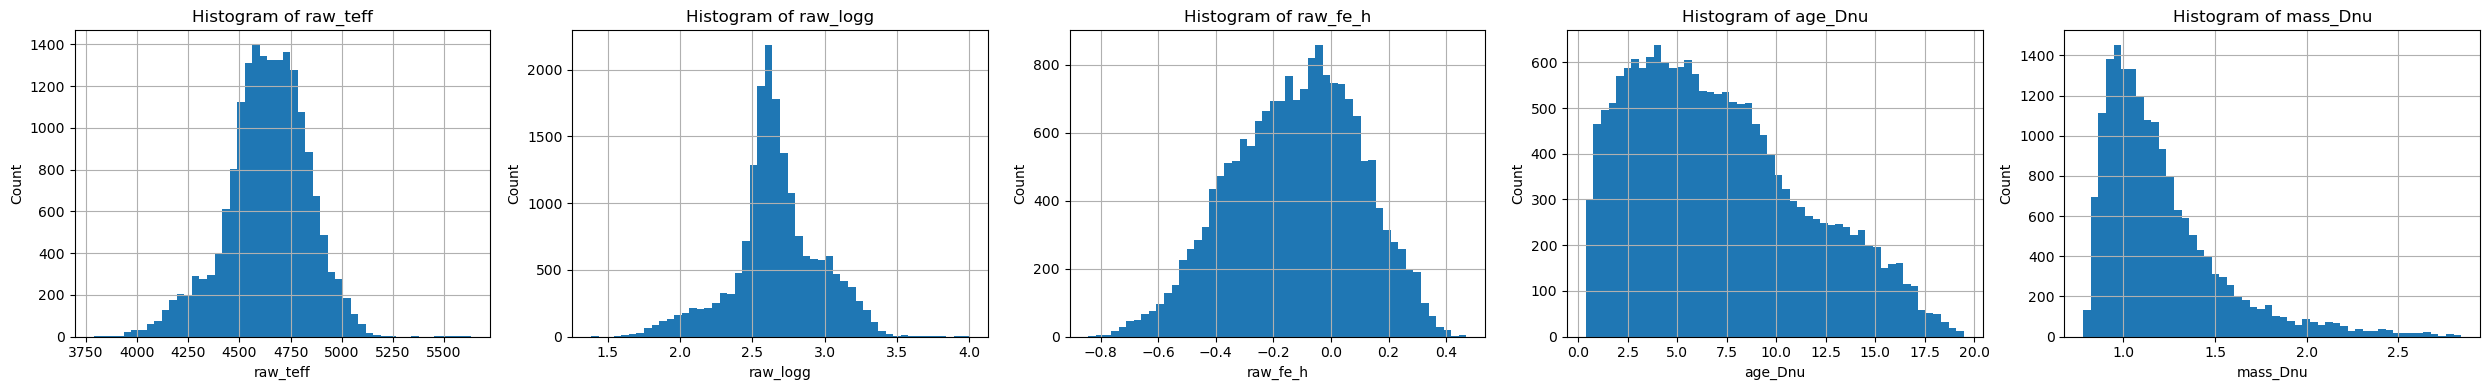

In [78]:
import matplotlib.pyplot as plt

# Select some interesting features/columns (edit as needed)
features = [
    'raw_teff',        # Effective temperature
    'raw_logg',        # Surface gravity
    'raw_fe_h',        # Metallicity
    'age_Dnu',         # Age from spectra
    'mass_Dnu',        # Mass estimate
]
# Only plot features that exist in the dataframe
features_to_plot = [col for col in features if col in cleaned.columns]

n_features = len(features_to_plot)
plt.figure(figsize=(5 * n_features, 4))

for i, feature in enumerate(features_to_plot):
    plt.subplot(1, n_features, i + 1)
    cleaned[feature].hist(bins=50)
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.title(f'Histogram of {feature}')

plt.tight_layout()
plt.show()

In [79]:
cleaned.to_parquet(SRC / 'data' / 'cleaned_ages.parquet')